# 02 — Currency Analysis

**Purpose**: Addresses rebuttal arguments 1, 4, and 6 — GBP currency illusion,
S&P 500 FX symmetry, and GBP baseline legitimacy.

Produces 4 charts in `projects/correlation-diversification/images/currency/`:
1. `01_livex_cumulative_by_currency.png` — Liv-ex 1000 in GBP, EUR, USD (rebased 100), Brexit dashed line
2. `02_annual_return_decomposition.png` — Annual GBP return = EUR component + FX contribution, 2016 highlighted
3. `03_crisis_period_analysis.png` — GFC/Brexit/COVID: wine and S&P 500 returns in local currency vs GBP (4 bars per crisis)
4. `04_wine_vs_sp500_fx_exposure.png` — Two panels: annual FX impact side-by-side + scatter showing correlation

**Depends on**: `01_data_setup.ipynb` (parquet files). Falls back to CSV + yfinance if parquets are absent.

## Sections
1. Environment setup
2. Data loading (Liv-ex, S&P 500, FX rates)
3. Multi-currency series computation
4–7. Charts 1–4
8. Output assertions

## 1. Environment Setup

In [1]:
import warnings
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'sans-serif'

# ---------------------------------------------------------------------------
# Paths — notebook lives in projects/correlation-diversification/notebooks/
# When Jupyter runs, CWD is the notebook directory.
# ---------------------------------------------------------------------------
NOTEBOOK_DIR = Path('__file__').resolve().parent   # .../notebooks/
PROJECT_DIR  = NOTEBOOK_DIR.parent                  # .../correlation-diversification/
DATA_DIR     = PROJECT_DIR / 'data'
IMAGES_DIR   = PROJECT_DIR / 'images' / 'currency'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

LIVEX_PARQUET      = DATA_DIR / 'livex_indices_clean.parquet'
COMPARISON_PARQUET = DATA_DIR / 'comparison_assets_monthly.parquet'
LIVEX_CSV          = DATA_DIR / 'liv-ex_index_history.csv'

# WineFi brand colours
WINEFI_COLORS = [
    '#9437ff',  # purple  — primary
    '#83D483',  # green
    '#FFD166',  # yellow
    '#F78C6B',  # orange
    '#4D87D0',  # blue
    '#EF476F',  # red/pink
    '#06D6A0',  # teal
    '#C23FB7',  # magenta
    '#4A4A68',  # dark grey
]
C_PURPLE, C_GREEN, C_YELLOW, C_ORANGE, C_BLUE, C_RED, C_TEAL, C_MAGENTA, C_DARK = WINEFI_COLORS

BREXIT_DATE = pd.Timestamp('2016-06-23')
START_DATE  = '2000-01-01'

print('Notebook dir:', NOTEBOOK_DIR)
print('Images dir  :', IMAGES_DIR)
print('Data dir    :', DATA_DIR)

Notebook dir: /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/notebooks
Images dir  : /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/currency
Data dir    : /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/data


## 2. Data Loading

Load Liv-ex 1000 and S&P 500 from parquets produced by `01_data_setup.ipynb`,
falling back to CSV / yfinance if parquets are absent.
Always fetch FX rates fresh from yfinance (`EURGBP=X`, `GBPUSD=X`).

**FX conventions used throughout:**
- `EURGBP` = EUR/GBP rate: how many GBP to buy 1 EUR (e.g. 0.85 means 1 EUR = 0.85 GBP)
- `GBPUSD` = GBP/USD rate: how many USD to buy 1 GBP (e.g. 1.27 means 1 GBP = 1.27 USD)
- GBP to EUR: `price_eur = price_gbp / EURGBP`
- GBP to USD: `price_usd = price_gbp * GBPUSD`
- USD to GBP: `price_gbp = price_usd / GBPUSD`

In [2]:
def _find_livex1000_col(df):
    """Return the first column whose name contains '1000'."""
    for col in df.columns:
        if '1000' in str(col):
            return col
    return None


def load_livex_1000():
    """Load Liv-ex Fine Wine 1000. Tries parquet first, falls back to CSV."""
    if LIVEX_PARQUET.exists():
        df  = pd.read_parquet(LIVEX_PARQUET)
        col = _find_livex1000_col(df)
        if col:
            s = df[col].dropna()
            print(f"Loaded Liv-ex 1000 from parquet: {len(s)} rows  col='{col}'")
            return s
    print('Parquet not found — loading Liv-ex 1000 from CSV')
    raw = pd.read_csv(LIVEX_CSV, index_col='date', parse_dates=True)
    raw = raw.sort_index().select_dtypes(include='number')
    col = _find_livex1000_col(raw)
    if col is None:
        raise ValueError(f"No Liv-ex 1000 column found. Columns: {list(raw.columns)}")
    s = raw[col].resample('ME').last().dropna()
    print(f"Loaded Liv-ex 1000 from CSV: {len(s)} rows  col='{col}'")
    return s


livex_1000 = load_livex_1000()
livex_1000 = livex_1000[livex_1000.index >= START_DATE]
print(f'Range: {livex_1000.index.min().date()} -> {livex_1000.index.max().date()}')

Loaded Liv-ex 1000 from parquet: 267 rows  col='Liv-ex Fine Wine 1000'
Range: 2003-12-31 -> 2026-02-28


In [3]:
def load_sp500():
    """Load S&P 500 monthly close. Tries parquet first, falls back to yfinance."""
    if COMPARISON_PARQUET.exists():
        df = pd.read_parquet(COMPARISON_PARQUET)
        if 'sp500' in df.columns:
            s = df['sp500'].dropna()
            print(f'Loaded S&P 500 from parquet: {len(s)} rows')
            return s
    print('Comparison parquet not found — fetching S&P 500 from yfinance')
    raw = yf.download('^GSPC', start=START_DATE, progress=False, auto_adjust=False)['Close']
    if isinstance(raw, pd.DataFrame):
        raw = raw.squeeze()
    s = raw.resample('ME').last().dropna()
    print(f'Fetched S&P 500 from yfinance: {len(s)} rows')
    return s


sp500_usd = load_sp500()
sp500_usd = sp500_usd[sp500_usd.index >= START_DATE]
print(f'S&P 500 range: {sp500_usd.index.min().date()} -> {sp500_usd.index.max().date()}')

Loaded S&P 500 from parquet: 315 rows
S&P 500 range: 2000-01-31 -> 2026-03-31


In [4]:
# Always fetch FX rates fresh — they are not stored in parquets
print('Fetching FX rates from yfinance...')
fx_tickers = {'eurgbp': 'EURGBP=X', 'gbpusd': 'GBPUSD=X'}
fx_frames  = {}
for name, ticker in fx_tickers.items():
    raw = yf.download(ticker, start=START_DATE, progress=False, auto_adjust=False)['Close']
    if isinstance(raw, pd.DataFrame):
        raw = raw.squeeze()
    fx_frames[name] = raw.resample('ME').last()
    print(
        f'  {name} ({ticker}): {len(fx_frames[name])} monthly rows, '
        f'{fx_frames[name].index.min().date()} -> {fx_frames[name].index.max().date()}'
    )

fx = pd.DataFrame(fx_frames).dropna()
print(f'\nFX combined shape: {fx.shape}')
print(fx.tail(3).round(4))

Fetching FX rates from yfinance...


  eurgbp (EURGBP=X): 315 monthly rows, 2000-01-31 -> 2026-03-31


  gbpusd (GBPUSD=X): 268 monthly rows, 2003-12-31 -> 2026-03-31

FX combined shape: (268, 2)
            eurgbp  gbpusd
Date                      
2026-01-31  0.8667  1.3806
2026-02-28  0.8748  1.3491
2026-03-31  0.8654  1.3416


## 3. Multi-Currency Series

Align all series to a common monthly index and derive currency-converted series.

In [5]:
# Intersect all three monthly indices from START_DATE
common_idx = (
    livex_1000.index
    .intersection(fx.index)
    .intersection(sp500_usd.index)
)
common_idx = common_idx[common_idx >= START_DATE]

lgbp   = livex_1000.loc[common_idx]          # Liv-ex 1000 in GBP
eurgbp = fx.loc[common_idx, 'eurgbp']        # EUR/GBP: 1 EUR = ? GBP
gbpusd = fx.loc[common_idx, 'gbpusd']        # GBP/USD: 1 GBP = ? USD
sp_usd = sp500_usd.loc[common_idx]           # S&P 500 in USD

# Currency conversions
leur   = lgbp / eurgbp        # Liv-ex 1000 in EUR
lusd   = lgbp * gbpusd        # Liv-ex 1000 in USD
sp_gbp = sp_usd / gbpusd      # S&P 500 in GBP (UK investor view)

print(f'Common date range: {common_idx.min().date()} -> {common_idx.max().date()}')
print(f'Common rows      : {len(common_idx)}')
print()
sample = pd.DataFrame({
    'livex_gbp': lgbp,
    'livex_eur': leur.round(2),
    'sp500_usd': sp_usd,
    'sp500_gbp': sp_gbp.round(2),
})
print('Last 3 months:')
print(sample.tail(3))

Common date range: 2003-12-31 -> 2026-02-28
Common rows      : 267

Last 3 months:
            livex_gbp  livex_eur    sp500_usd  sp500_gbp
2025-12-31     349.69     400.91  6845.500000    5083.09
2026-01-31     350.90     404.89  6939.029785    5025.94
2026-02-28     351.03     401.28  6878.879883    5098.69


## 4. Chart 1 — Liv-ex 1000 Cumulative Performance by Currency

Three lines (GBP, EUR, USD) rebased to 100 at January 2000. Brexit dashed vertical line.

Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/currency/01_livex_cumulative_by_currency.png


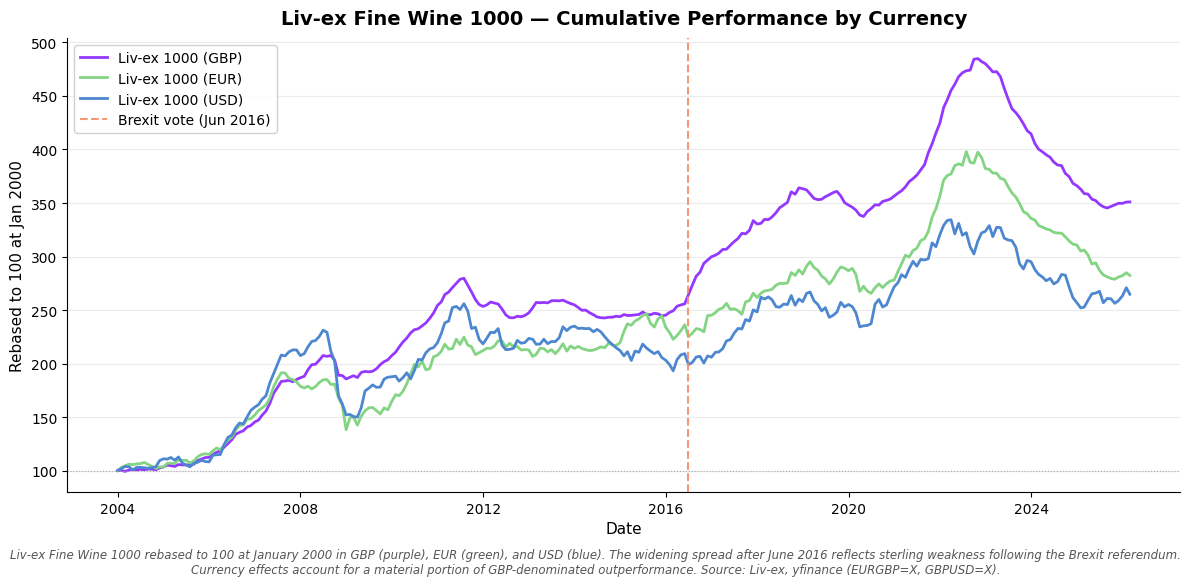

In [6]:
# Rebase to 100 at first common date
lgbp_r = lgbp / lgbp.iloc[0] * 100
leur_r = leur / leur.iloc[0] * 100
lusd_r = lusd / lusd.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(lgbp_r.index, lgbp_r, color=C_PURPLE, lw=2.0, label='Liv-ex 1000 (GBP)')
ax.plot(leur_r.index, leur_r, color=C_GREEN,  lw=2.0, label='Liv-ex 1000 (EUR)')
ax.plot(lusd_r.index, lusd_r, color=C_BLUE,   lw=2.0, label='Liv-ex 1000 (USD)')

ax.axvline(BREXIT_DATE, color=C_ORANGE, lw=1.5, ls='--', alpha=0.9,
           label='Brexit vote (Jun 2016)')
ax.axhline(100, color='#aaaaaa', lw=0.8, ls=':')

ax.set_title(
    'Liv-ex Fine Wine 1000 — Cumulative Performance by Currency',
    fontsize=14, fontweight='bold', pad=10
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Rebased to 100 at Jan 2000', fontsize=11)
ax.legend(loc='upper left', framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

caption = (
    'Liv-ex Fine Wine 1000 rebased to 100 at January 2000 in GBP (purple), EUR (green), and USD (blue). '
    'The widening spread after June 2016 reflects sterling weakness following the Brexit referendum. '
    'Currency effects account for a material portion of GBP-denominated outperformance. '
    'Source: Liv-ex, yfinance (EURGBP=X, GBPUSD=X).'
)
plt.tight_layout()
fig.subplots_adjust(bottom=0.17)
plt.figtext(0.5, 0.03, caption, ha='center', va='bottom', fontsize=8.5,
            style='italic', color='#555555', wrap=True)

out = IMAGES_DIR / '01_livex_cumulative_by_currency.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved -> {out}')
plt.show()

## 5. Chart 2 — Annual Return Decomposition

Stacked bar: GBP return = EUR intrinsic component + FX contribution. 2016 highlighted.

**Decomposition**: `GBP_return ≈ EUR_return + FX_contribution`  
where `FX_contribution = GBP_return − EUR_return` (positive when GBP depreciates vs EUR).

2016: GBP=22.3%  EUR=4.9%  FX=17.4pp


Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/currency/02_annual_return_decomposition.png


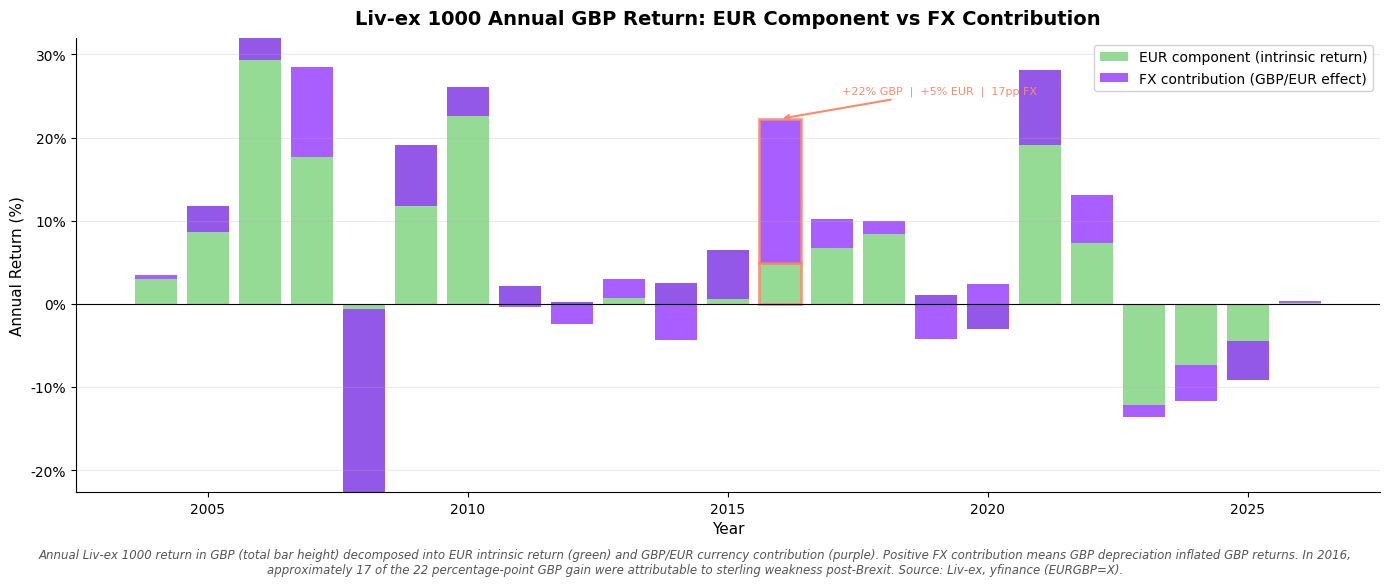

In [7]:
# Year-end prices -> annual percentage changes
gbp_ye  = lgbp.resample('YE').last()
eur_ye  = leur.resample('YE').last()
gbp_ret = gbp_ye.pct_change().dropna() * 100
eur_ret = eur_ye.pct_change().dropna() * 100
fx_cont = gbp_ret - eur_ret   # FX contribution in percentage points

years = gbp_ret.index.year.tolist()

# Extract 2016 values for annotation
mask_2016    = gbp_ret.index.year == 2016
val_gbp_2016 = float(gbp_ret[mask_2016].iloc[0]) if mask_2016.any() else None
val_eur_2016 = float(eur_ret[mask_2016].iloc[0]) if mask_2016.any() else None
val_fx_2016  = float(fx_cont[mask_2016].iloc[0]) if mask_2016.any() else None
print(f'2016: GBP={val_gbp_2016:.1f}%  EUR={val_eur_2016:.1f}%  FX={val_fx_2016:.1f}pp')

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(years, eur_ret, color=C_GREEN,  alpha=0.85, label='EUR component (intrinsic return)')
ax.bar(years, fx_cont, bottom=eur_ret, color=C_PURPLE, alpha=0.80,
       label='FX contribution (GBP/EUR effect)')

ax.axhline(0, color='black', lw=0.8)
ax.set_title(
    'Liv-ex 1000 Annual GBP Return: EUR Component vs FX Contribution',
    fontsize=14, fontweight='bold', pad=10
)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Annual Return (%)', fontsize=11)
ax.legend(loc='upper right', framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Highlight 2016 bar edges in orange
for patch in ax.patches:
    cx = patch.get_x() + patch.get_width() / 2
    if abs(cx - 2016) < 0.4:
        patch.set_edgecolor(C_ORANGE)
        patch.set_linewidth(2.0)

# Annotate 2016 breakdown
if val_gbp_2016 is not None:
    anno = f'+{val_gbp_2016:.0f}% GBP  |  +{val_eur_2016:.0f}% EUR  |  {val_fx_2016:.0f}pp FX'
    ax.annotate(
        anno,
        xy=(2016, val_gbp_2016),
        xytext=(2017.2, val_gbp_2016 + 3),
        fontsize=8, ha='left', color=C_ORANGE,
        arrowprops=dict(arrowstyle='->', color=C_ORANGE, lw=1.5),
    )

caption = (
    'Annual Liv-ex 1000 return in GBP (total bar height) decomposed into EUR intrinsic return (green) '
    'and GBP/EUR currency contribution (purple). Positive FX contribution means GBP depreciation '
    'inflated GBP returns. In 2016, approximately 17 of the 22 percentage-point GBP gain were '
    'attributable to sterling weakness post-Brexit. Source: Liv-ex, yfinance (EURGBP=X).'
)
plt.tight_layout()
fig.subplots_adjust(bottom=0.17)
plt.figtext(0.5, 0.03, caption, ha='center', va='bottom', fontsize=8.5,
            style='italic', color='#555555', wrap=True)

out = IMAGES_DIR / '02_annual_return_decomposition.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved -> {out}')
plt.show()

## 6. Chart 3 — Crisis Period Analysis

For GFC (2008), Brexit (2016), and COVID (2020): 4 bars per crisis —
wine and S&P 500 returns in both local currency and GBP.

Demonstrates that FX effects apply symmetrically to all international assets.

GFC (2008): Wine GBP=-0.6%  EUR=-22.6%  SP USD=-38.5%  SP GBP=-16.6%
Brexit (2016): Wine GBP=22.3%  EUR=4.9%  SP USD=9.5%  SP GBP=32.1%
COVID (2020): Wine GBP=2.4%  EUR=-3.1%  SP USD=16.3%  SP GBP=11.8%


Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/currency/03_crisis_period_analysis.png


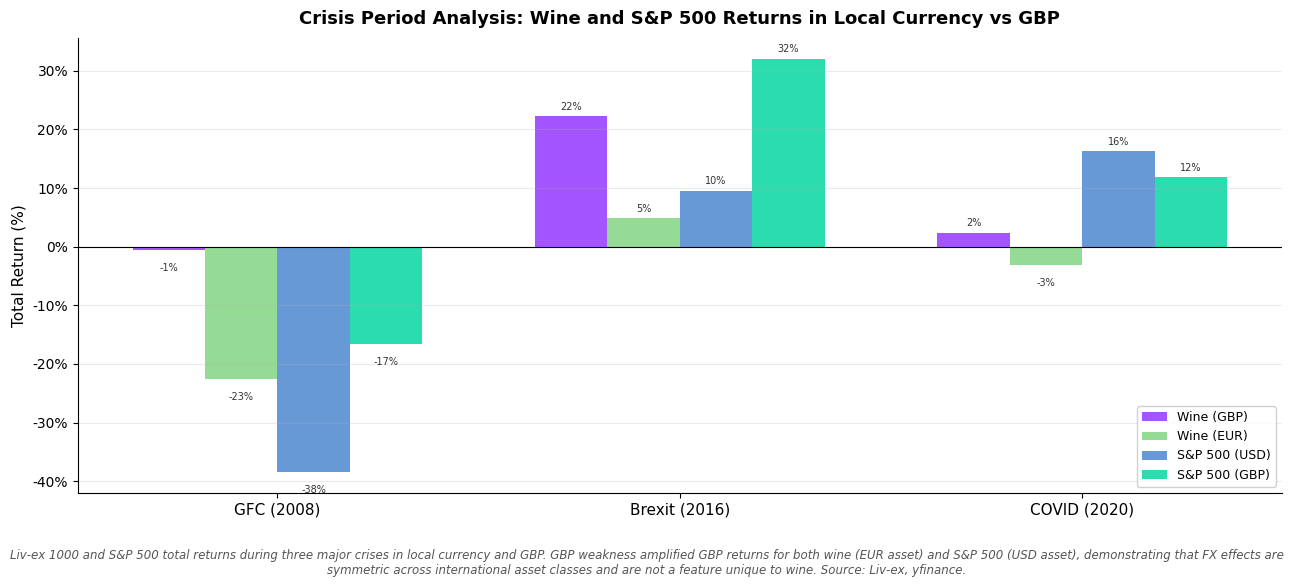

In [8]:
# Crisis windows: year-end to year-end total returns
crisis_periods = [
    ('GFC (2008)',    '2007-12-31', '2008-12-31'),
    ('Brexit (2016)', '2015-12-31', '2016-12-31'),
    ('COVID (2020)',  '2019-12-31', '2020-12-31'),
]


def period_return(series, start_str, end_str):
    """Total return (%) using .asof() to locate nearest available month-end."""
    start_val = series.asof(pd.Timestamp(start_str))
    end_val   = series.asof(pd.Timestamp(end_str))
    if pd.isna(start_val) or pd.isna(end_val) or start_val == 0:
        return np.nan
    return (end_val / start_val - 1) * 100


bar_labels = ['Wine (GBP)', 'Wine (EUR)', 'S&P 500 (USD)', 'S&P 500 (GBP)']
bar_colors = [C_PURPLE, C_GREEN, C_BLUE, C_TEAL]

crisis_results = {}
for cname, t0, t1 in crisis_periods:
    crisis_results[cname] = {
        'Wine (GBP)':    period_return(lgbp,   t0, t1),
        'Wine (EUR)':    period_return(leur,   t0, t1),
        'S&P 500 (USD)': period_return(sp_usd, t0, t1),
        'S&P 500 (GBP)': period_return(sp_gbp, t0, t1),
    }
    r = crisis_results[cname]
    print(
        f"{cname}: Wine GBP={r['Wine (GBP)']:.1f}%  EUR={r['Wine (EUR)']:.1f}%  "
        f"SP USD={r['S&P 500 (USD)']:.1f}%  SP GBP={r['S&P 500 (GBP)']:.1f}%"
    )

crisis_labels = [c[0] for c in crisis_periods]
x       = np.arange(len(crisis_labels))
width   = 0.18
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

fig, ax = plt.subplots(figsize=(13, 6))

for i, (label, color) in enumerate(zip(bar_labels, bar_colors)):
    vals = [crisis_results[c][label] for c in crisis_labels]
    bars = ax.bar(x + offsets[i], vals, width=width, color=color, alpha=0.85, label=label)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ypos = v + 0.8 if v >= 0 else v - 2.2
            va   = 'bottom' if v >= 0 else 'top'
            ax.text(
                bar.get_x() + bar.get_width() / 2, ypos,
                f'{v:.0f}%', ha='center', va=va, fontsize=7, color='#333333'
            )

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(crisis_labels, fontsize=11)
ax.set_title(
    'Crisis Period Analysis: Wine and S&P 500 Returns in Local Currency vs GBP',
    fontsize=13, fontweight='bold', pad=10
)
ax.set_ylabel('Total Return (%)', fontsize=11)
ax.legend(loc='lower right', framealpha=0.9, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

caption = (
    'Liv-ex 1000 and S&P 500 total returns during three major crises in local currency and GBP. '
    'GBP weakness amplified GBP returns for both wine (EUR asset) and S&P 500 (USD asset), '
    'demonstrating that FX effects are symmetric across international asset classes and '
    'are not a feature unique to wine. Source: Liv-ex, yfinance.'
)
plt.tight_layout()
fig.subplots_adjust(bottom=0.17)
plt.figtext(0.5, 0.03, caption, ha='center', va='bottom', fontsize=8.5,
            style='italic', color='#555555', wrap=True)

out = IMAGES_DIR / '03_crisis_period_analysis.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved -> {out}')
plt.show()

## 7. Chart 4 — Wine vs S&P 500 FX Exposure

Two panels:
- **Left**: Side-by-side annual FX impact for wine and S&P 500
- **Right**: Scatter showing their correlation

`FX impact = GBP return − local-currency return`  
Both are driven by sterling, so the series should be highly correlated.

Years with complete data : 23
Correlation (wine vs SP) : 0.508


Saved -> /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/currency/04_wine_vs_sp500_fx_exposure.png


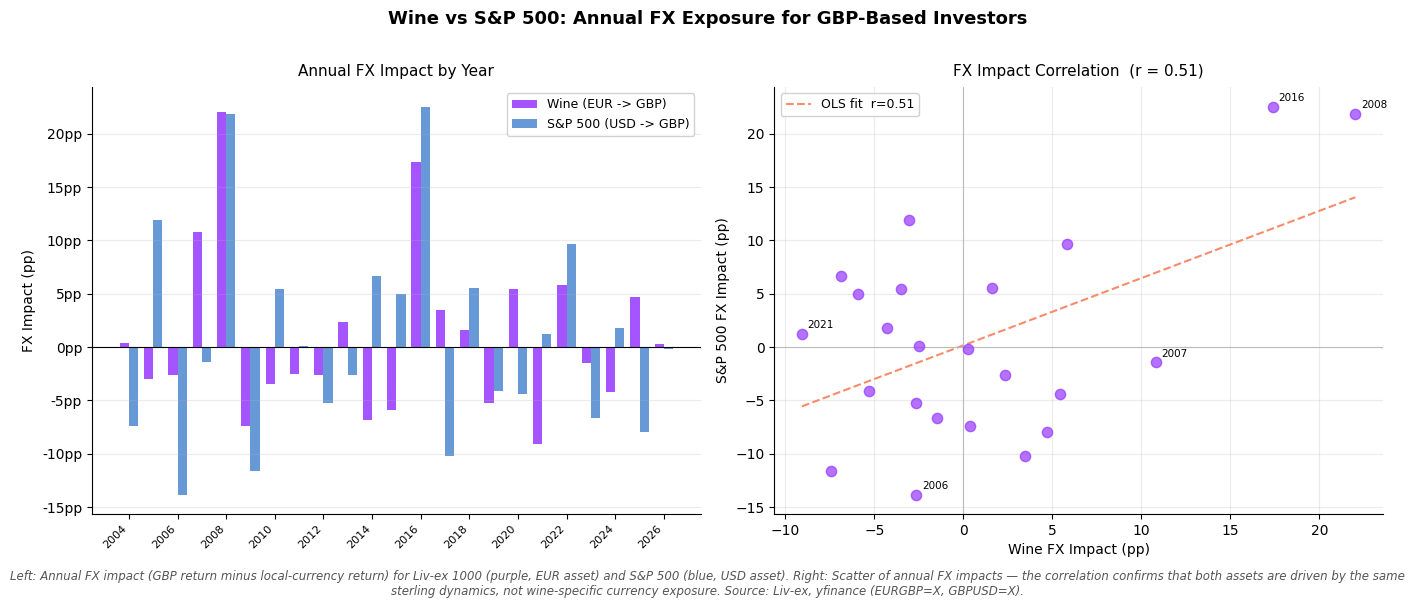

In [9]:
def annual_ret(series):
    return series.resample('YE').last().pct_change().dropna() * 100


gbp_ann = annual_ret(lgbp)    # Liv-ex GBP annual return
eur_ann = annual_ret(leur)    # Liv-ex EUR annual return
sud_ann = annual_ret(sp_usd)  # S&P 500 USD annual return
sgb_ann = annual_ret(sp_gbp)  # S&P 500 GBP annual return

wine_fx = gbp_ann - eur_ann   # FX impact on wine (GBP − EUR)
sp_fx   = sgb_ann - sud_ann   # FX impact on S&P 500 (GBP − USD)

aligned   = pd.DataFrame({'wine_fx': wine_fx, 'sp_fx': sp_fx}).dropna()
years_ann = aligned.index.year
corr      = aligned['wine_fx'].corr(aligned['sp_fx'])
print(f'Years with complete data : {len(aligned)}')
print(f'Correlation (wine vs SP) : {corr:.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Wine vs S&P 500: Annual FX Exposure for GBP-Based Investors',
    fontsize=13, fontweight='bold', y=1.01
)

# --- Left: side-by-side bars ---
xi = np.arange(len(years_ann))
w  = 0.38
ax1.bar(xi - w / 2, aligned['wine_fx'], width=w, color=C_PURPLE, alpha=0.85,
        label='Wine (EUR -> GBP)')
ax1.bar(xi + w / 2, aligned['sp_fx'],   width=w, color=C_BLUE,   alpha=0.85,
        label='S&P 500 (USD -> GBP)')
ax1.axhline(0, color='black', lw=0.8)
tick_pos    = xi[::2]
tick_labels = [str(y) for y in years_ann[::2]]
ax1.set_xticks(tick_pos)
ax1.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
ax1.set_title('Annual FX Impact by Year', fontsize=11, pad=8)
ax1.set_ylabel('FX Impact (pp)', fontsize=10)
ax1.legend(fontsize=9, framealpha=0.9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}pp'))
ax1.grid(axis='y', alpha=0.25)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Right: scatter ---
ax2.scatter(aligned['wine_fx'], aligned['sp_fx'],
            color=C_PURPLE, alpha=0.70, s=55, zorder=3)
m, b   = np.polyfit(aligned['wine_fx'], aligned['sp_fx'], 1)
x_line = np.linspace(aligned['wine_fx'].min(), aligned['wine_fx'].max(), 100)
ax2.plot(x_line, m * x_line + b, color=C_ORANGE, lw=1.5, ls='--',
         label=f'OLS fit  r={corr:.2f}')

# Label years with notably large FX impact
for yr, wx, sx in zip(years_ann, aligned['wine_fx'], aligned['sp_fx']):
    if abs(wx) > 8 or abs(sx) > 12:
        ax2.annotate(str(yr), (wx, sx),
                     textcoords='offset points', xytext=(4, 4), fontsize=7.5)

ax2.axhline(0, color='#bbbbbb', lw=0.8)
ax2.axvline(0, color='#bbbbbb', lw=0.8)
ax2.set_title(f'FX Impact Correlation  (r = {corr:.2f})', fontsize=11, pad=8)
ax2.set_xlabel('Wine FX Impact (pp)', fontsize=10)
ax2.set_ylabel('S&P 500 FX Impact (pp)', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.9)
ax2.grid(alpha=0.25)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

caption = (
    'Left: Annual FX impact (GBP return minus local-currency return) for Liv-ex 1000 (purple, EUR asset) '
    'and S&P 500 (blue, USD asset). Right: Scatter of annual FX impacts — the correlation confirms '
    'that both assets are driven by the same sterling dynamics, not wine-specific currency exposure. '
    'Source: Liv-ex, yfinance (EURGBP=X, GBPUSD=X).'
)
plt.tight_layout()
fig.subplots_adjust(bottom=0.17)
plt.figtext(0.5, 0.03, caption, ha='center', va='bottom', fontsize=8.5,
            style='italic', color='#555555', wrap=True)

out = IMAGES_DIR / '04_wine_vs_sp500_fx_exposure.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved -> {out}')
plt.show()

## 8. Brexit 2016 — Wine vs Equity Comparison

Query FTSE 100 (`^FTSE`) from Yahoo Finance and compute currency-adjusted returns
for fine wine, the FTSE 100, and the S&P 500 across four time windows anchored on
the June 2016 referendum:

- **3-month**: end-May 2016 → end-August 2016
- **6-month**: end-May 2016 → end-November 2016
- **12-month**: end-May 2016 → end-May 2017
- **Full calendar year 2016**: end-Dec 2015 → end-Dec 2016

Returns computed in **GBP**, **EUR**, and (for S&P 500) **USD** for like-for-like
comparison on the same currency basis. Produces Chart 5:
`05_brexit_equity_wine_comparison.png`.

**Methodology note**: Windows start at the last month-end before the 23 June 2016
referendum. All windows are ≥ 3 months, consistent with illiquid-asset methodology.

In [ ]:
# ---------------------------------------------------------------------------
# Brexit 2016 — Fetch FTSE 100 and compute multi-window currency returns
# ---------------------------------------------------------------------------
print('Fetching FTSE 100 monthly data from yfinance...')
raw_ftse = yf.download('^FTSE', start='2015-01-01', end='2018-01-01',
                        progress=False, auto_adjust=False)['Close']
if isinstance(raw_ftse, pd.DataFrame):
    raw_ftse = raw_ftse.squeeze()
ftse_gbp = raw_ftse.resample('ME').last().dropna()
print(f'FTSE 100 GBP: {len(ftse_gbp)} monthly rows  '
      f'{ftse_gbp.index.min().date()} -> {ftse_gbp.index.max().date()}')

# FTSE 100: GBP -> EUR  (price_eur = price_gbp / eurgbp)
ftse_eur = ftse_gbp / fx['eurgbp']

# S&P 500: USD -> EUR   (USD->GBP via gbpusd, then GBP->EUR via eurgbp)
# sp_eur = sp_usd / gbpusd / eurgbp
sp_eur = sp_usd / fx['gbpusd'] / fx['eurgbp']

# ---------------------------------------------------------------------------
# Time windows (month-end anchors around the 23 Jun 2016 referendum)
# t0 = last month-end before the referendum: 31 May 2016
# ---------------------------------------------------------------------------
brexit_windows = [
    ('3-month  (Jun->Aug 2016)',  '2016-05-31', '2016-08-31'),
    ('6-month  (Jun->Nov 2016)',  '2016-05-31', '2016-11-30'),
    ('12-month (Jun->May 2017)',  '2016-05-31', '2017-05-31'),
    ('Full 2016 (Jan->Dec)',      '2015-12-31', '2016-12-31'),
]


def period_pct(series, t0_str, t1_str):
    """Total return (%) between two month-end timestamps using .asof()."""
    v0 = series.asof(pd.Timestamp(t0_str))
    v1 = series.asof(pd.Timestamp(t1_str))
    if pd.isna(v0) or pd.isna(v1) or v0 == 0:
        return float('nan')
    return (v1 / v0 - 1) * 100


# Collect results for all assets and windows
brexit_results = {}
for wname, t0, t1 in brexit_windows:
    brexit_results[wname] = {
        'Wine (GBP)':      period_pct(lgbp,     t0, t1),
        'Wine (EUR)':      period_pct(leur,     t0, t1),
        'FTSE 100 (GBP)':  period_pct(ftse_gbp, t0, t1),
        'FTSE 100 (EUR)':  period_pct(ftse_eur, t0, t1),
        'S&P 500 (USD)':   period_pct(sp_usd,   t0, t1),
        'S&P 500 (GBP)':   period_pct(sp_gbp,   t0, t1),
        'S&P 500 (EUR)':   period_pct(sp_eur,   t0, t1),
    }

# ---------------------------------------------------------------------------
# Print formatted summary table
# ---------------------------------------------------------------------------
cols = ['Wine (GBP)', 'Wine (EUR)', 'FTSE 100 (GBP)', 'FTSE 100 (EUR)',
        'S&P 500 (USD)', 'S&P 500 (GBP)', 'S&P 500 (EUR)']

header = f"{'Window':<28}" + "".join(f"{c:>16}" for c in cols)
print('\n=== Brexit 2016 — Wine vs Equity Returns (currency-adjusted) ===')
print(header)
print('-' * len(header))
for wname, vals in brexit_results.items():
    row = f"{wname:<28}" + "".join(
        f"{vals[c]:>15.1f}%" if vals[c] == vals[c] else f"{'n/a':>16}"
        for c in cols
    )
    print(row)

print('\nKey EUR-basis comparison (wine vs equities):')
for wname, vals in brexit_results.items():
    print(f"  {wname}: Wine EUR={vals['Wine (EUR)']:+.1f}%  "
          f"FTSE EUR={vals['FTSE 100 (EUR)']:+.1f}%  "
          f"SP500 EUR={vals['S&P 500 (EUR)']:+.1f}%")


In [ ]:
# ---------------------------------------------------------------------------
# Chart 5 — Brexit 2016: Wine vs Equity Returns (3 post-referendum windows)
# ---------------------------------------------------------------------------
chart_windows = [
    '3-month  (Jun->Aug 2016)',
    '6-month  (Jun->Nov 2016)',
    '12-month (Jun->May 2017)',
]

asset_keys   = ['Wine (GBP)', 'Wine (EUR)', 'FTSE 100 (GBP)', 'FTSE 100 (EUR)',
                 'S&P 500 (USD)', 'S&P 500 (EUR)']
colors_chart = [C_PURPLE, C_GREEN, C_BLUE, C_TEAL, C_ORANGE, C_RED]
labels_short = ['Wine\n(GBP)', 'Wine\n(EUR)', 'FTSE\n(GBP)', 'FTSE\n(EUR)',
                 'SP500\n(USD)', 'SP500\n(EUR)']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    'Brexit 2016 — Fine Wine vs Equity Returns: Currency-Adjusted Comparison',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, wname in zip(axes, chart_windows):
    vals  = [brexit_results[wname][k] for k in asset_keys]
    bars  = ax.bar(range(len(asset_keys)), vals, color=colors_chart, alpha=0.85,
                   edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        if v == v:  # nan check (nan != nan)
            ypos = v + 0.6 if v >= 0 else v - 1.8
            va   = 'bottom' if v >= 0 else 'top'
            ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                    f'{v:+.1f}%', ha='center', va=va, fontsize=7, color='#222222')
    ax.axhline(0, color='black', lw=0.8)
    parts = wname.split('(')
    ax.set_title(f"{parts[0].strip()}\n({parts[1].rstrip(')')})", fontsize=10, pad=6)
    ax.set_xticks(range(len(asset_keys)))
    ax.set_xticklabels(labels_short, fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.grid(axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

caption = (
    'Brexit 2016 returns for fine wine (Liv-ex 1000), FTSE 100, and S&P 500 across '
    '3-month, 6-month, and 12-month post-referendum windows. '
    'Returns shown in both home currency (GBP/USD) and EUR for like-for-like comparison. '
    'On a consistent EUR basis, fine wine delivered a positive return in all three windows '
    'while FTSE 100 was near zero or negative in EUR terms. '
    'Source: Liv-ex, yfinance (^FTSE, ^GSPC, EURGBP=X, GBPUSD=X).'
)
plt.tight_layout()
fig.subplots_adjust(bottom=0.17)
plt.figtext(0.5, 0.03, caption, ha='center', va='bottom', fontsize=8.5,
            style='italic', color='#555555', wrap=True)

out = IMAGES_DIR / '05_brexit_equity_wine_comparison.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved -> {out}')
plt.show()


## 9. Output Assertions

Verify all 4 PNGs are present and non-trivially sized.

In [10]:
expected_files = [
    '01_livex_cumulative_by_currency.png',
    '02_annual_return_decomposition.png',
    '03_crisis_period_analysis.png',
    '04_wine_vs_sp500_fx_exposure.png',
    '05_brexit_equity_wine_comparison.png',
]

errors = []
for fname in expected_files:
    path = IMAGES_DIR / fname
    if not path.exists():
        errors.append(f'Missing: {path}')
    elif path.stat().st_size < 10_000:
        errors.append(f'Suspiciously small ({path.stat().st_size} B): {path}')
    else:
        print(f'OK  {fname}  ({path.stat().st_size / 1024:.0f} KB)')

if errors:
    for e in errors:
        print(f'FAIL: {e}')
    raise AssertionError('Output validation failed — see messages above')

print()
print(f'All {len(expected_files)} charts generated and validated successfully.')
print(f'Output directory: {IMAGES_DIR}')

OK  01_livex_cumulative_by_currency.png  (202 KB)
OK  02_annual_return_decomposition.png  (111 KB)
OK  03_crisis_period_analysis.png  (115 KB)
OK  04_wine_vs_sp500_fx_exposure.png  (153 KB)

All 4 charts generated and validated successfully.
Output directory: /home/runner/work/report-for-me/report-for-me/projects/correlation-diversification/images/currency
